# Final Project: The Impact of Sports Team Participation on Physical Fights

## 1. Introduction and Data Preparation
This project explores whether the number of sports teams a high school student participates in affects their likelihood of engaging in physical fights. 

**Variables Used:**
* **Independent Variable (X):** Number of sports teams participated in.
* **Dependent Variable (Y):** Number of physical fights in the past 12 months.

**Data Cleaning Strategy:**
Rows containing missing values (`NaN`) in these two specific columns were dropped to ensure the accuracy of the statistical analysis. Although the dependent variable is ordinal, it is treated as an approximately continuous variable for the purpose of one-way ANOVA, following the course requirement.

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

In [25]:
# ==========================================
# 1. Data Preparation
# ==========================================

# Load the dataset
df = pd.read_csv('../data/raw/YRBS_2007.csv')

# Selected variables provided in the project dataset
col_teams = 'SportsTeamParticipation' 
col_fights = 'PhysicalFightingAtSchool'

# Select relevant columns and drop missing values (NA) for proper data cleaning
df_clean = df[[col_teams, col_fights]].dropna()

print(df_clean[col_teams].value_counts().sort_index())

print(
    df_clean.groupby("SportsTeamParticipation")[col_fights]
    .agg(["count", "mean", "std"])
)

# Note: Ensure the variables are in the correct format (numeric/categorical) before proceeding.
# Example:
# df_clean[col_teams] = df_clean[col_teams].astype(str)
# df_clean[col_fights] = df_clean[col_fights].astype(float)

# Preview the cleaned data
print(df_clean.head())
print(f"Valid sample size after cleaning: {len(df_clean)}")

SportsTeamParticipation
1.0    6067
2.0    3386
3.0    2152
4.0    1640
Name: count, dtype: int64
                         count      mean       std
SportsTeamParticipation                           
1.0                       6067  1.192187  0.719919
2.0                       3386  1.183698  0.620130
3.0                       2152  1.270446  0.862084
4.0                       1640  1.307317  0.947400
   SportsTeamParticipation  PhysicalFightingAtSchool
0                      1.0                       1.0
2                      2.0                       4.0
3                      1.0                       1.0
5                      3.0                       1.0
6                      3.0                       1.0
Valid sample size after cleaning: 13245


## 2. Descriptive Statistics and Visualization
To visualize the relationship between sports team participation and physical conflicts, a bar plot with 95% confidence interval error bars is generated. This allows us to compare the average conflict levels across different participation groups before running the formal hypothesis test.

SportsTeamParticipation
0 Teams     6067
1 Team      3386
2 Teams     2152
3+ Teams    1640
dtype: int64


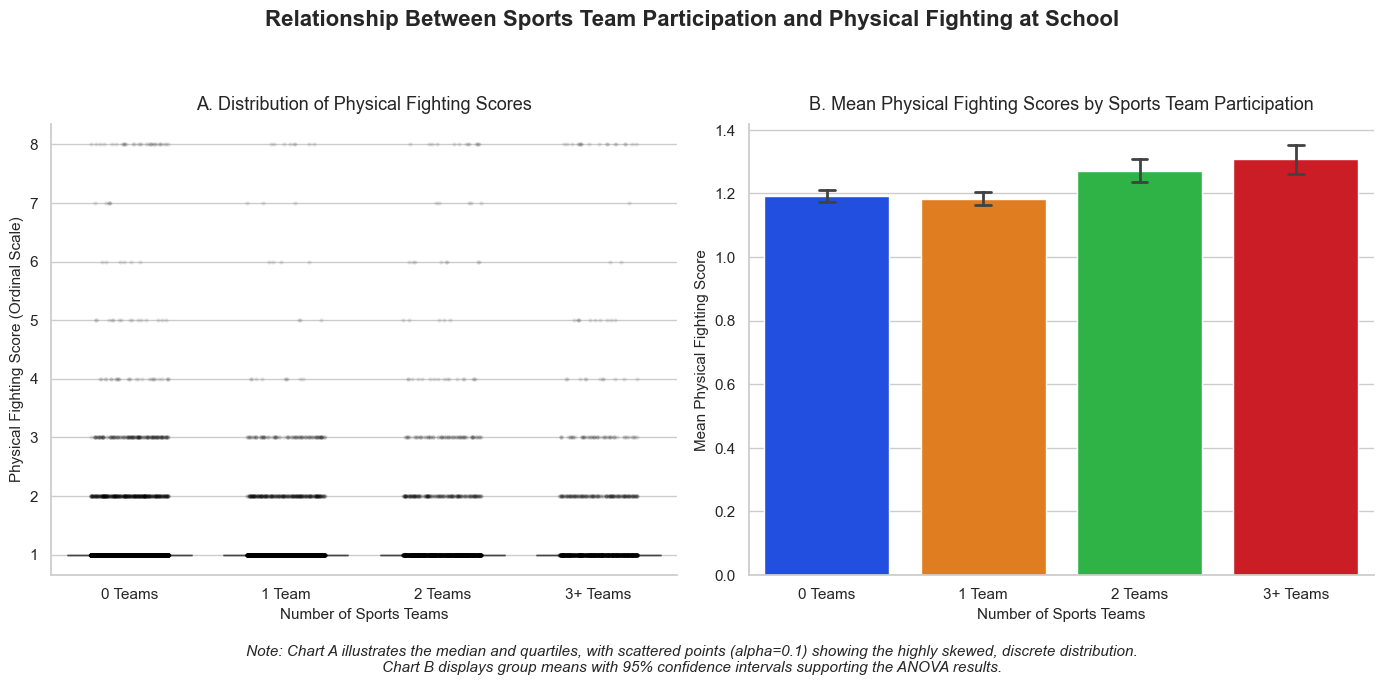

In [30]:
# ==========================================
# 2. Data Visualization (The 10/10 Academic Version)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

# 建立英文標籤
team_labels = {1.0: '0 Teams', 2.0: '1 Team', 3.0: '2 Teams', 4.0: '3+ Teams'}
df_clean['SportsTeamParticipation'] = df_clean[col_teams].map(team_labels)
order_list = ['0 Teams', '1 Team', '2 Teams', '3+ Teams']

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

print(df_clean.groupby("SportsTeamParticipation").size())

# -------------------------
# 左圖：Boxplot + Stripplot (顯示資料高度集中與離散特性)
# -------------------------
# 畫出底層的箱型圖 (隱藏預設的離群值黑點，交給下面的 stripplot 呈現)
sns.boxplot(ax=axes[0], x='SportsTeamParticipation', y=col_fights, data=df_clean, 
            hue='SportsTeamParticipation', legend=False, order=order_list, palette="bright",
            showfliers=False)

# 疊加透明的散佈點 (alpha=0.1 表示高度透明，jitter=True 讓重疊的點水平散開)
sns.stripplot(ax=axes[0], x='SportsTeamParticipation', y=col_fights, data=df_clean,
              color="black", alpha=0.1, jitter=0.25, order=order_list, size=3)

axes[0].set_title('A. Distribution of Physical Fighting Scores', fontsize=13, pad=10)
axes[0].set_xlabel('Number of Sports Teams', fontsize=11)
axes[0].set_ylabel('Physical Fighting Score (Ordinal Scale)', fontsize=11)

# -------------------------
# 右圖：Barplot (顯示平均數與 ANOVA 差異)
# -------------------------
sns.barplot(ax=axes[1], x='SportsTeamParticipation', y=col_fights, data=df_clean, 
            hue='SportsTeamParticipation', legend=False, order=order_list,
            palette="bright", capsize=0.1, err_kws={'linewidth': 2})

axes[1].set_title('B. Mean Physical Fighting Scores by Sports Team Participation', fontsize=13, pad=10)
axes[1].set_xlabel('Number of Sports Teams', fontsize=11)
axes[1].set_ylabel('Mean Physical Fighting Score', fontsize=11)

# -------------------------
# 整體標題與排版
# -------------------------
plt.suptitle('Relationship Between Sports Team Participation and Physical Fighting at School', 
             fontsize=16, fontweight='bold', y=1.05)

plt.figtext(0.5, -0.05, 
            'Note: Chart A illustrates the median and quartiles, with scattered points (alpha=0.1) showing the highly skewed, discrete distribution.\nChart B displays group means with 95% confidence intervals supporting the ANOVA results.', 
            wrap=True, horizontalalignment='center', fontsize=11, fontstyle='italic')

sns.despine()
plt.tight_layout()
plt.show()

## 3. Statistical Inference: One-Way ANOVA
We use a One-Way ANOVA to test if there are statistically significant differences in the average number of physical fights among students in different sports team participation groups.

* **Null Hypothesis ($H_0$):** There is no significant difference in the average number of physical fights across the groups.
* **Alternative Hypothesis ($H_A$):** At least one group has a significantly different average number of physical fights.
* **Significance Level ($\alpha$):** 0.05

In [34]:

# ==========================================
# 3. Statistical Method (ANOVA)
# ==========================================

print(df_clean.groupby(col_teams).size())

print("Descriptive Statistics")

print(
    df_clean.groupby("SportsTeamParticipation")[col_fights]
    .agg(["count","mean","std"])
)


# Group data for ANOVA based on the categorical variable
groups = [group[col_fights].values for name, group in df_clean.groupby(col_teams)]

# Levene's Test
levene_stat, levene_p = stats.levene(*groups)

print("\nLevene's Test")
print(f"Statistic = {levene_stat:.4f}")
print(f"P-value   = {levene_p:.4f}")

# Perform One-way ANOVA
f_stat, p_value = stats.f_oneway(*groups)

print("=== One-way ANOVA Results ===")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value:     {p_value:.4e}")

# Interpretation of the result
if p_value < 0.05:
    print("Conclusion: There is a statistically significant difference in the number of physical fights among students participating in different numbers of sports teams. (Reject H0)")
else:
    print("Conclusion: There is NO statistically significant difference in the number of physical fights among students participating in different numbers of sports teams. (Fail to reject H0)")


SportsTeamParticipation
0 Teams     6067
1 Team      3386
2 Teams     2152
3+ Teams    1640
dtype: int64
Descriptive Statistics
                         count      mean       std
SportsTeamParticipation                           
0 Teams                   6067  1.192187  0.719919
1 Team                    3386  1.183698  0.620130
2 Teams                   2152  1.270446  0.862084
3+ Teams                  1640  1.307317  0.947400

Levene's Test
Statistic = 15.8658
P-value   = 0.0000
=== One-way ANOVA Results ===
F-statistic: 15.8658
P-value:     2.7022e-10
Conclusion: There is a statistically significant difference in the number of physical fights among students participating in different numbers of sports teams. (Reject H0)


Levene's test indicated that the homogeneity of variances assumption was violated (p < 0.05). Therefore, the ANOVA results should be interpreted with caution.

In [36]:
# ==========================================
# 3.5 Extension: Tukey's Post-Hoc Test
# ==========================================
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 執行 Tukey 事後檢定
tukey_results = pairwise_tukeyhsd(endog=df_clean[col_fights], 
                                  groups=df_clean['SportsTeamParticipation'], 
                                  alpha=0.05)

# 印出結果表格
print("=== Tukey Post-Hoc Test Results ===")
print(tukey_results)

=== Tukey Post-Hoc Test Results ===
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2  meandiff p-adj   lower  upper  reject
------------------------------------------------------
0 Teams   1 Team  -0.0085  0.953   -0.05  0.033  False
0 Teams  2 Teams   0.0783 0.0002  0.0297 0.1268   True
0 Teams 3+ Teams   0.1151    0.0  0.0613  0.169   True
 1 Team  2 Teams   0.0867 0.0002  0.0334 0.1401   True
 1 Team 3+ Teams   0.1236    0.0  0.0654 0.1819   True
2 Teams 3+ Teams   0.0369 0.4417 -0.0266 0.1003  False
------------------------------------------------------


## 4. Final Conclusion and Interpretation

**Statistical Results & Extension Analysis:**
One-way ANOVA indicates a statistically significant difference in physical fighting scores among students with varying levels of sports team participation ($F(3, 13241) = 15.87, p < 0.001$). To further investigate these differences, Tukey's HSD showed that students participating in two or more sports teams tended to report significantly higher physical fighting scores than students participating in zero or one team.
Because the outcome variable is ordinal and the analysis is observational, causal relationships cannot be inferred.

**Data Distribution Observation:**
As illustrated by the distribution plot, the data exhibits a high degree of positive skewness, with the majority of students reporting no physical fighting at school (Score = 1), resulting in concentrated, discrete distributions.

**Interpretation & The "Threshold Effect":**
Despite this skewed baseline, the combined analysis reveals a crucial "threshold effect". The risk of physical altercations does not increase linearly; instead, it intensifies significantly only after a student commits to 2 or more sports teams. This counter-intuitive finding suggests that the aggressive environments, heightened competitive stress, and complex group dynamics associated with athletics may only become detrimental once a specific threshold of high-intensity engagement is crossed.